In [1]:
path_to_add = os.path.abspath('../')
sys.path.append(path_to_add)
from func_curvefit import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
s=24 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [3]:
x = np.arange(0,1.01,.01)

In [4]:
def return_bias(bias_xmin,bias_xmax):
    return bias_xmin/(bias_xmin + bias_xmax)

In [5]:
results_loc = '../../results/schematics/linefitting'

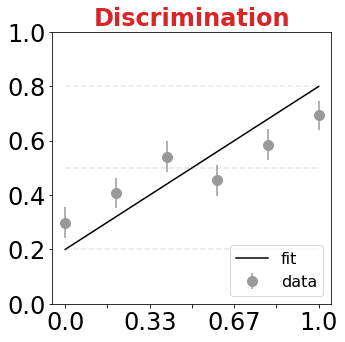

In [74]:
fig, ax = plt.subplots(figsize=(5,5),nrows=1,ncols=1)

bias_xmin = .2
# bias_xmax = .2
slope = .6
ypred = linear(x,slope,bias_xmin) # bias_xmin + amplitude * sigmoid(x, sigma, center)
bias_xmax = 1-linear(1,slope,bias_xmin)
bias = return_bias(bias_xmin,bias_xmax)
amplitude = 1-bias_xmin-bias_xmax

ax.plot(x,ypred, color = 'k', label = 'fit')

inds = [0,20,40,60,80,100] # pick 6 evenly spaced events
x_fakedata = x[inds]

# Generate the noise
noise_signs = np.array([1, 1, 1, -1, -1, -1])
np.random.shuffle(noise_signs)
# noise_magnitude = np.random.uniform(0, 0.1, len(inds))

# Apply the noise to the selected data points
y_fakedata = [ypred[inds] + noise_signs * np.random.uniform(0, 0.2, len(inds)) for i in range(100)]
y_fakedata = np.array(y_fakedata)

# Calculate mean and standard deviation across rows for each column
y_mean = np.mean(y_fakedata, axis=0)
y_std = np.std(y_fakedata, axis=0)

ax.errorbar(x_fakedata, y_mean, yerr=y_std, color = [.6,.6,.6],marker = 'o',markersize=10,ls='None', label = 'data')

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Discrimination', fontweight='bold', color = 'tab:red')
ax.set_xticks(np.linspace(0,1,7))
ax.set_xticklabels([str(np.round(i,2)) if ind in [0,2,4,6] else ' ' for ind, i in enumerate(np.linspace(0,1,7))])
ax.set_ylim(0,1)

plt.hlines(bias_xmin,0,1,color = 'grey',alpha = .2, ls = '--')
plt.hlines(1-bias_xmax,0,1,color = 'grey',alpha = .2, ls = '--')
plt.hlines(.5,0,1,color = 'grey',alpha = .2, ls = '--')

ax.legend(loc='lower right',fontsize=16) # center left

plt.savefig(f'{results_loc}/plain_schematic.png',dpi=300, bbox_inches='tight')

In [9]:
s=20 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

range_color = '#FF8000' # [255,128,0] # orange
bias_color =  '#5F00A0' #[95,0,160] # purple
PSE_color =  '#00A651' #[0,166,81] # green

# bias

In [10]:
from matplotlib.font_manager import FontProperties

In [11]:
# Enable LaTeX formatting globally
plt.rcParams['text.usetex'] = False # not working!


In [48]:
colors_all = ['k','k','k'] #[[.8,.8,.8],[0,0,0],[.6,.6,.6]]
ls_all =   [':','-',(0, (5, 10))] #[':','-','-.'] #[':','-','-.'] #[':','-','--']

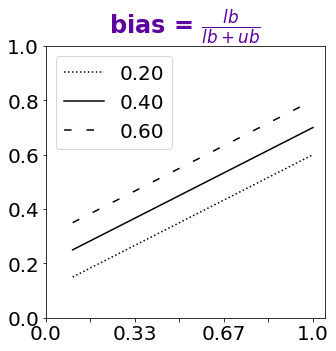

In [49]:
fig, ax = plt.subplots(figsize=(5,5),nrows=1,ncols=1)

bias_xmin_all = [.1,.2,.3]
bias_xmax_all = [.3,.2,.1]
legend_pos = 'upper left'
title = 'Bias levels'

bias_xmin = bias_xmin_all[0]# y-value at lowest x
slope = .5
bias_xmax = 1-linear(1,slope,bias_xmin)
amplitude = 1-bias_xmin-bias_xmax
bias = return_bias(bias_xmin,bias_xmax)

ypred = linear(x, slope, bias_xmin)
ax.plot(x,ypred, color = colors_all[0], label = f'{bias:.2f}',ls=ls_all[0])

bias_xmin = bias_xmin_all[1]# y-value at lowest x
slope = .5
bias_xmax = 1-linear(1,slope,bias_xmin)
bias = return_bias(bias_xmin,bias_xmax)
amplitude = 1-bias_xmin-bias_xmax
ypred = linear(x, slope, bias_xmin)
ax.plot(x,ypred, color = colors_all[1], label = f'{bias:.2f}',ls=ls_all[1])


bias_xmin = bias_xmin_all[2]# y-value at lowest x
slope = .5
bias_xmax = 1-linear(1,slope,bias_xmin)
bias = return_bias(bias_xmin,bias_xmax)
amplitude = 1-bias_xmin-bias_xmax
ypred = linear(x, slope, bias_xmin)
ax.plot(x,ypred, color = colors_all[2], label = f'{bias:.2f}',ls=ls_all[2])
ax.set_ylim(0,1)

ax.set_title(r'bias = $\frac{lb}{lb + ub}$', fontweight='bold', fontsize=24, color = bias_color)
ax.set_xlabel('')
ax.set_ylabel('')

ax.set_xticks(np.linspace(0,1,7))
ax.set_xticklabels([str(np.round(i,2)) if ind in [0,2,4,6] else ' ' for ind, i in enumerate(np.linspace(0,1,7))])

ax.legend()
legend =  ax.legend() #title='bias',
# Customize legend text colors
for i in range(3):
    legend.get_texts()[i].set_color(colors_all[i])

plt.savefig(f'{results_loc}/bias_schematic_1option.png',dpi=300, bbox_inches='tight')

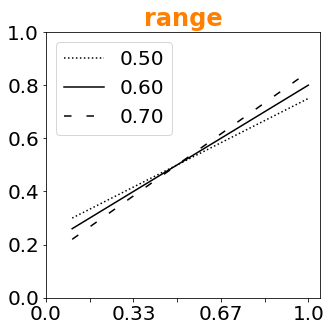

In [53]:
fig, ax = plt.subplots(figsize=(5,5),nrows=1,ncols=1)

bias_xmin_all = [.25,.2,.15]
slopes_all = [.5,.6,.7]

for i in range(3):

    bias_xmin = bias_xmin_all[i]
    slope = slopes_all[i]
    # bias_xmax = bias_xmin_all[i]
    bias_xmax = 1-linear(1,slope,bias_xmin)
    bias = return_bias(bias_xmin,bias_xmax)

    amplitude = 1-bias_xmin-bias_xmax

    ypred = linear(x, slope, bias_xmin)
    ax.plot(x,ypred, color = colors_all[i], label = f'{amplitude:.2f}',ls=ls_all[i])
    

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('range', fontweight='bold', color = range_color, fontsize = 24)

ax.set_xticks(np.linspace(0,1,7))
ax.set_xticklabels([str(np.round(i,2)) if ind in [0,2,4,6] else ' ' for ind, i in enumerate(np.linspace(0,1,7))])

legend =  ax.legend()#title='slope')
# Customize legend text colors
for i in range(3):
    legend.get_texts()[i].set_color(colors_all[i])

plt.ylim(0,1)
plt.tight_layout()

plt.savefig(f'{results_loc}/amplitude_schematic.png',dpi=300, bbox_inches='tight')